In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/single_genre_artists.csv")

df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (95837, 23)

Columns:
Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

Duplicate rows:
0


In [5]:
drop_columns = [
    'id_songs',
    'name_song',
    'name_artists'
]

df = df.drop(columns=drop_columns)

df.head()

,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists
0,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],22
1,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],22
2,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],22
3,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],22
4,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],22


In [6]:
df.columns

Index(['popularity_songs', 'duration_ms', 'explicit', 'id_artists',
       'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'popularity_artists'],
      dtype='object')

In [7]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

X = df[features]

X.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973


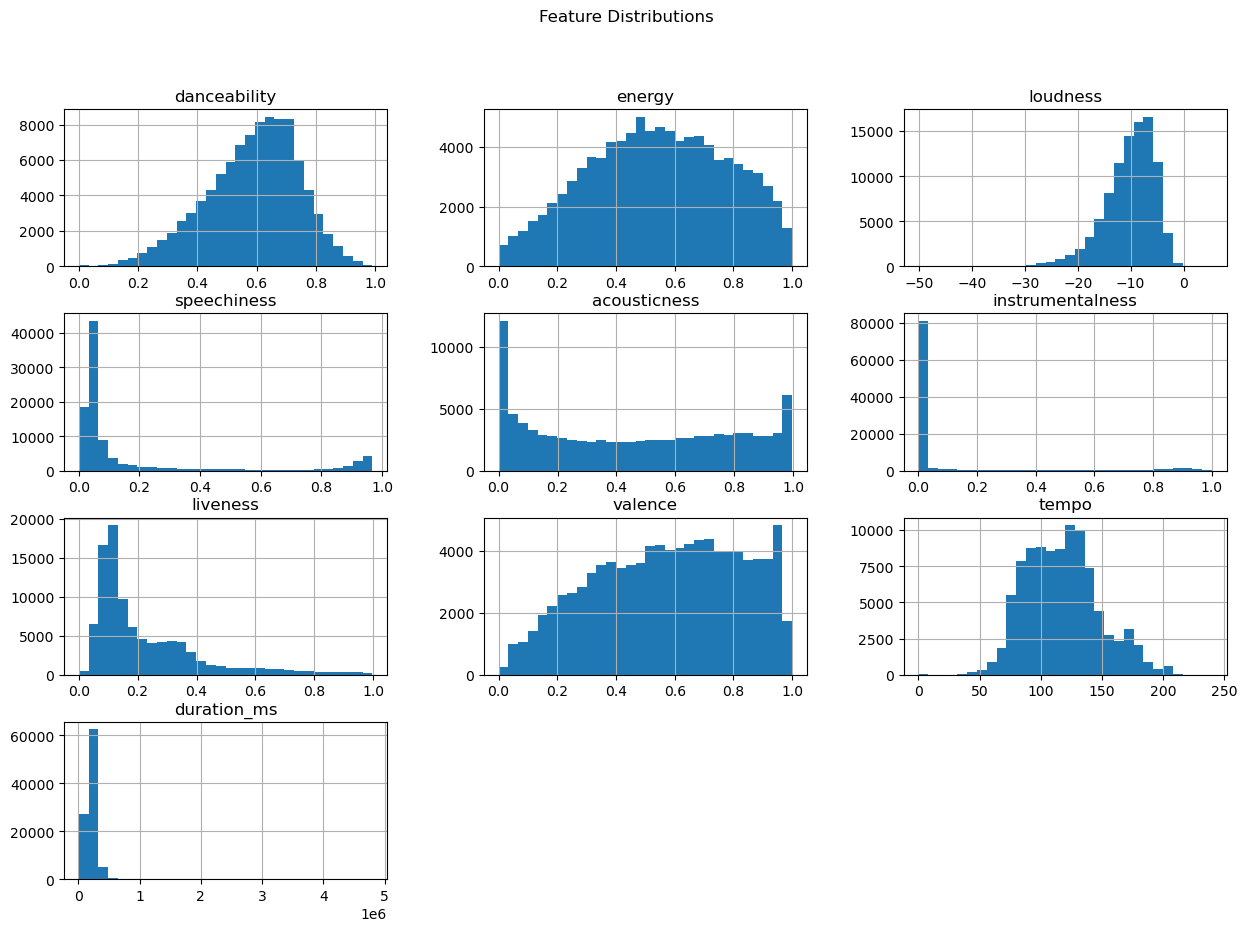

In [8]:
X.hist(figsize=(15,10), bins=30)

plt.suptitle("Feature Distributions")

plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [10]:
X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,-0.401735
1,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,0.124906
2,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,-0.003949
3,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,-0.397437
4,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,-0.346143


In [11]:
inertia = []

K = range(2, 11)

for k in K:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

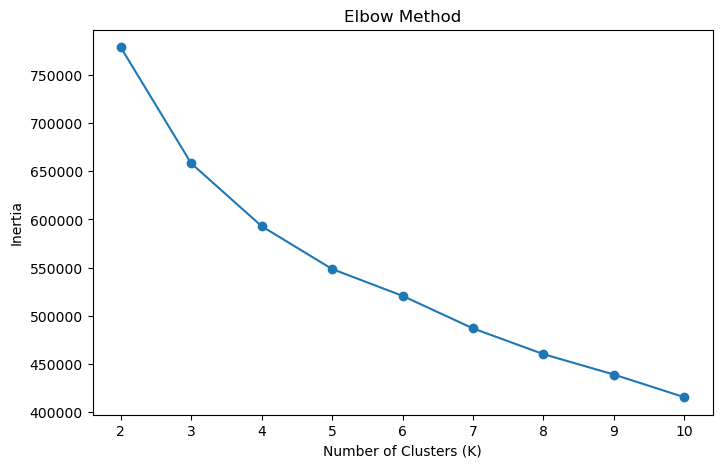

In [12]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [14]:
sample_data = X_scaled.sample(10000, random_state=42)

silhouette_scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(sample_data)

    score = silhouette_score(sample_data, labels)

    silhouette_scores.append(score)

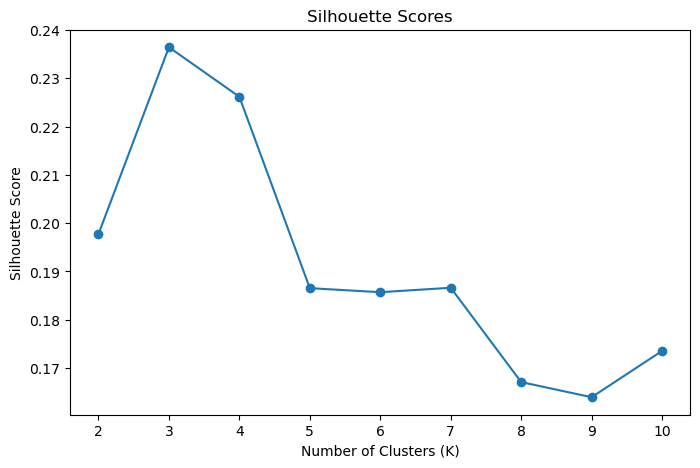

In [15]:
plt.figure(figsize=(8,5))

plt.plot(K, silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")

plt.show()

In [16]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,loudness,mode,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists,Cluster
0,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,-13.757,1,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],22,1
1,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,-15.375,1,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],22,1
2,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,-15.514,1,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],22,1
3,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,-12.393,0,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],22,1
4,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,-13.806,1,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],22,1


In [17]:
sil_score = silhouette_score(
    sample_data,
    kmeans.predict(sample_data)
)

db_score = davies_bouldin_score(
    X_scaled,
    df['Cluster']
)

print("Silhouette Score:", sil_score)

print("Davies-Bouldin Score:", db_score)

Silhouette Score: 0.23778857167911355
Davies-Bouldin Score: 1.5702159203045074


In [18]:
df['Cluster'].value_counts()

Cluster
2    52517
1    30807
0    12513
Name: count, dtype: int64

In [19]:
cluster_profile = df.groupby('Cluster')[features].mean()

cluster_profile

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
Cluster,,,,,,,,,,
0,0.664271,0.466636,-13.363885,0.829978,0.585932,0.001385,0.435535,0.584036,100.389473,97520.590026
1,0.486381,0.311231,-13.205013,0.060140,0.749228,0.168547,0.182070,0.413254,111.939598,223457.063979
2,0.627345,0.693655,-7.606487,0.075064,0.258485,0.050703,0.199867,0.666416,124.911397,226592.052516


## Cluster Interpretation

### Cluster 0: Speech-Heavy / Spoken Content Tracks
Cluster 0 has the highest speechiness value, moderate danceability, moderate acousticness, and relatively lower energy. This indicates that these tracks may contain more spoken-word elements compared to regular songs. These tracks may represent speech-heavy, podcast-like, or mellow content.

### Cluster 1: Acoustic / Instrumental / Calm Tracks
Cluster 1 has the highest acousticness and instrumentalness, along with low energy, low danceability, and lower valence. This suggests that these tracks are softer, calmer, and more instrumental or acoustic in nature. These songs may be suitable for relaxation or background listening.

### Cluster 2: Energetic / Upbeat Tracks
Cluster 2 has the highest energy, loudness, valence, and tempo, along with high danceability. This indicates that these tracks are more energetic, upbeat, and lively. These songs may be suitable for party, workout, or high-energy playlists.

In [20]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

df['PCA1'] = pca_data[:, 0]

df['PCA2'] = pca_data[:, 1]

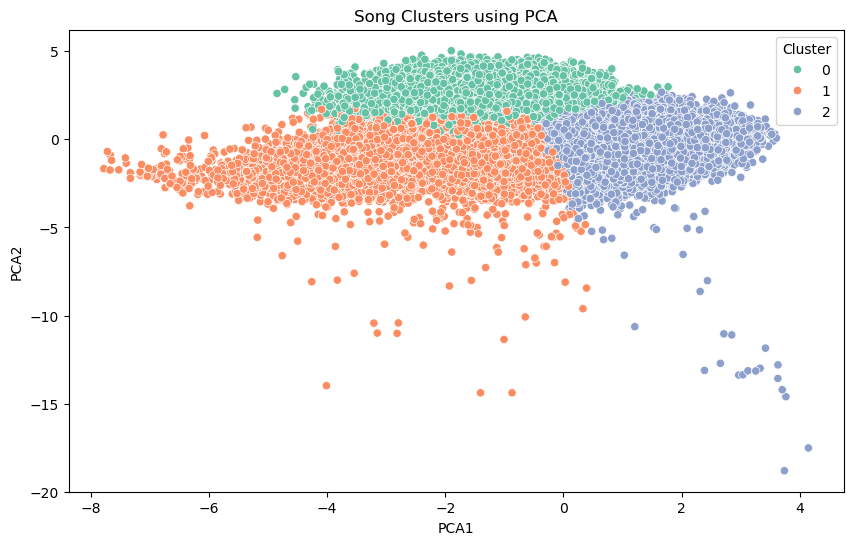

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2'
)

plt.title("Song Clusters using PCA")

plt.show()

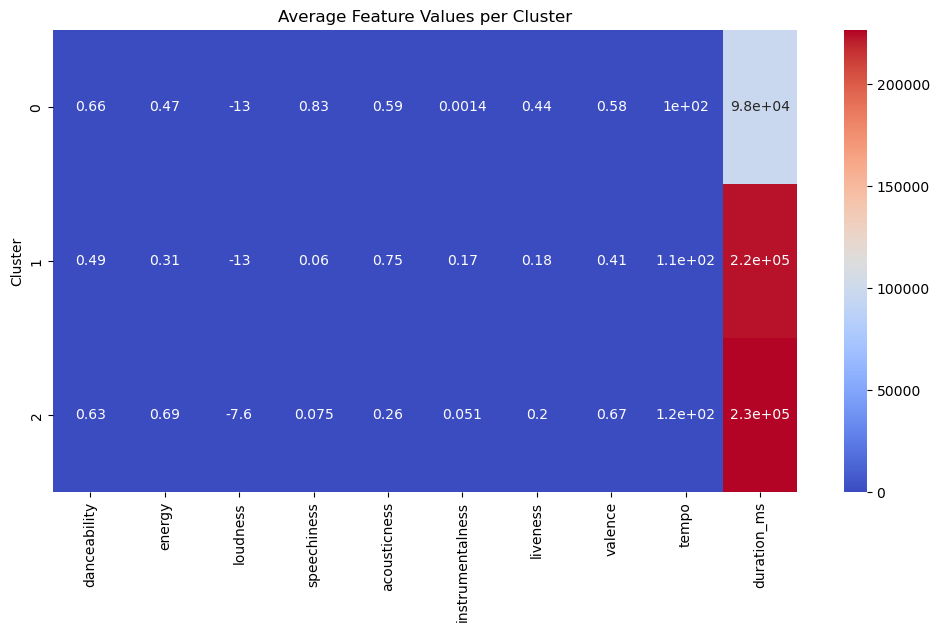

In [22]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='coolwarm'
)

plt.title("Average Feature Values per Cluster")

plt.show()

In [23]:
df.to_csv("../output/final_clustered_songs.csv", index=False)

print("File exported successfully")

File exported successfully


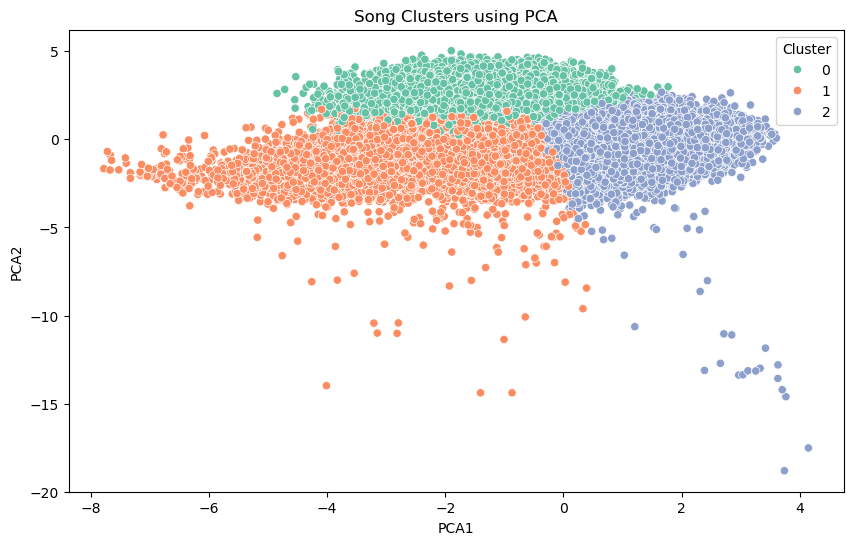

In [24]:
#Saving Plots
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='Set2'
)

plt.title("Song Clusters using PCA")

plt.savefig("../output/pca_clusters.png")

plt.show()

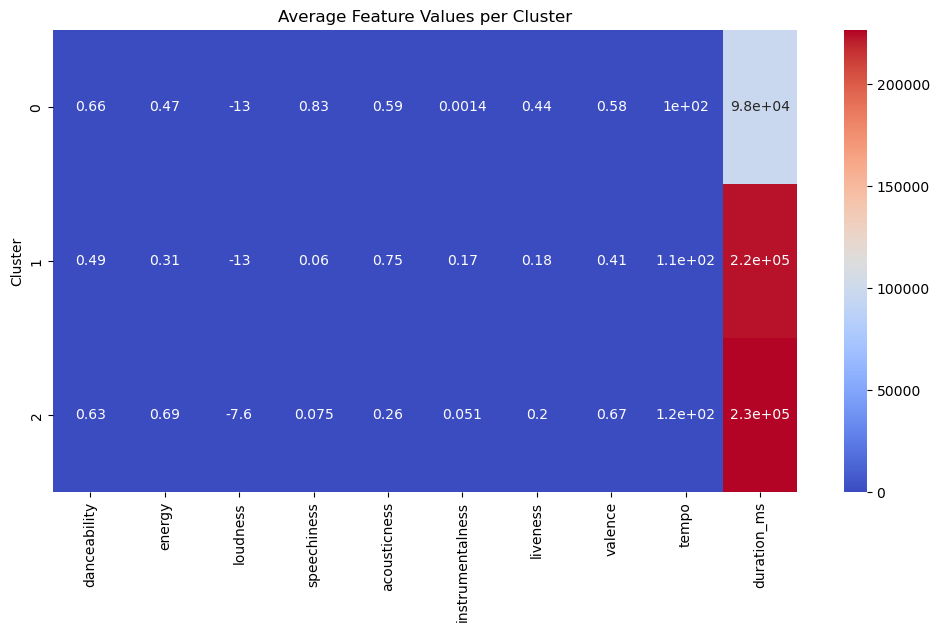

In [25]:
# Saving Heat Map
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='coolwarm'
)

plt.title("Average Feature Values per Cluster")

plt.savefig("../output/cluster_heatmap.png")

plt.show()